In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import LearningRateScheduler
import numpy as np

In [2]:
(Xtr,ytr),(Xts,yts)=mnist.load_data()
Xtr=Xtr/255
Xts=Xts/255

In [3]:
ytr=to_categorical(ytr,10)
yts=to_categorical(yts,10)


In [4]:
initial_learning_rate=0.01
batch_size=64
epochs=20
def lr_schedule(epoch,lr):
    if epoch>0 and epoch%3==0:
        return lr/2
    return lr



In [5]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
]
)


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
optimizer=SGD(learning_rate=initial_learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])



In [7]:
lr_scheduler=LearningRateScheduler(lr_schedule)
history=model.fit(Xtr,ytr,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(Xts,yts),
          callbacks=[lr_scheduler])

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7611 - loss: 0.9400 - val_accuracy: 0.8901 - val_loss: 0.4144 - learning_rate: 0.0100
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8968 - loss: 0.3751 - val_accuracy: 0.9099 - val_loss: 0.3190 - learning_rate: 0.0100
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9125 - loss: 0.3113 - val_accuracy: 0.9215 - val_loss: 0.2810 - learning_rate: 0.0100
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9200 - loss: 0.2818 - val_accuracy: 0.9237 - val_loss: 0.2677 - learning_rate: 0.0050
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9243 - loss: 0.2678 - val_accuracy: 0.9271 - val_loss: 0.2529 - learning_rate: 0.0050
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9281 - loss: 0.2554 - val_accuracy: 0.9292 - val_loss: 0.2447 - learning_rate: 0.0050
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9304 - loss: 0.2461 - 

In [8]:
test_loss,test_accuracy=model.evaluate(Xts,yts)
print(test_loss,test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9368 - loss: 0.2177
0.2176876664161682 0.9368000030517578


In [9]:
#copy the code and tweak the values in a new file

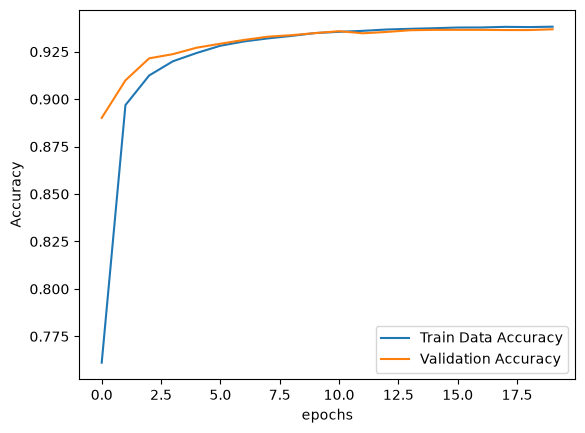

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="Train Data Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.show()

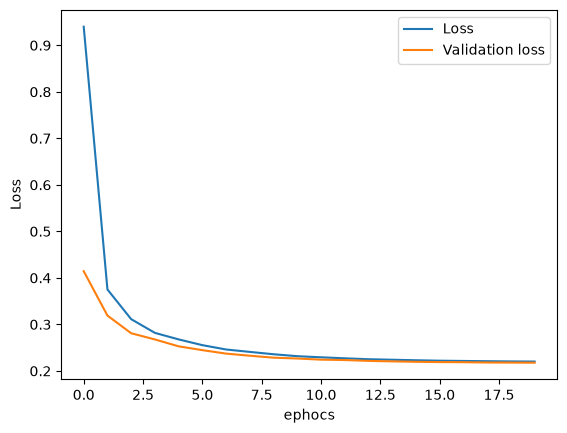

In [11]:
plt.plot(history.history["loss"],label="Loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.legend()
plt.xlabel("ephocs")
plt.ylabel("Loss")
plt.show()